# 🌾 Phénotypage architectural du sorgho avec SAM
**Segment Anything Model (Meta AI) + Extraction HSV OpenCV**

**Auteur :** Jamal

---
## Structure du notebook

| Cellule | Rôle |
|---|---|
| **1** | Installation des dépendances |
| **2** | Téléchargement checkpoint SAM |
| **3** | Google Drive + configuration |
| **4** | Chargement du modèle SAM |
| **5** | Paramètres globaux |
| **6** | Fonctions utilitaires |
| **A** | Calibration grille carrelage → facteur px/cm |
| **NEW-1** | Calibration interactive des seuils HSV (trackbars Colab) |
| **NEW-2** | Extraction plante sur tout le lot → images_nobg/ |
| **B** | Outil de clic interactif → points de référence |
| **C** | Validation sur image de référence |
| **D** | Traitement image par image |
| **E** | CSV individuel + fusion finale |

---
## Protocole de pointage
- **Panicule** : 1 point au centre de l'épi
- **Feuilles 1 à 8** : 1 point à la **pointe** de chaque feuille, haut → bas
- **Tige** : 1 point sur la tige nue partie basse

> ⚠️ Activer le GPU : `Exécution → Modifier le type d'exécution → T4 GPU`

In [1]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Thu May 21 02:33:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             44W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 📦 Cellule 1 — Installation

In [2]:
!pip install segment-anything -q
!pip install opencv-python-headless matplotlib pandas tqdm ipywidgets -q
print('✅ Packages installés')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 97.4 MB/s eta 0:00:00
✅ Packages installés


## 📥 Cellule 2 — Checkpoint SAM

In [3]:
import os
CHECKPOINT_DIR  = '/content/sam_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
MODEL_TYPE      = 'vit_b'
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, 'sam_vit_b.pth')
URL = 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth'
if not os.path.exists(CHECKPOINT_PATH):
    print('⏳ Téléchargement vit_b...')
    !wget -q --show-progress -O {CHECKPOINT_PATH} {URL}
print('✅ Checkpoint prêt')

⏳ Téléchargement vit_b...
/content/sam_checkp 100%[===================>] 357.67M   357MB/s    in 1.0s    
✅ Checkpoint prêt


In [4]:
from google.colab import drive
drive.mount('/content/drive')
import glob, os

Mounted at /content/drive


## 🗂️ Cellule 3 — Google Drive + configuration

In [105]:


# ---------------------------------------------------------------
# 🔧 MODIFIER CES CHEMINS
# ---------------------------------------------------------------
IMAGES_DIR      = '/content/drive/MyDrive/SAM_SORGHUM/imagesSorgum'
IMAGES_NOBG_DIR = '/content/drive/MyDrive/SAM_SORGHUM/folder2025/bg'
OUTPUT_DIR      = '/content/drive/MyDrive/SAM_SORGHUM/folder2025/outputs'
POINTS_JSON     = '/content/drive/MyDrive/SAM_SORGHUM/folder2025/gjeon/points_reference.json'
HSV_JSON        = '/content/drive/MyDrive/SAM_SORGHUM/folder2025/gjeon/hsv_seuils.json'

EXTENSIONS = ('.jpg', '.jpeg', '.png', '.tif', '.tiff')
for d in [OUTPUT_DIR, IMAGES_NOBG_DIR,
          os.path.join(OUTPUT_DIR, 'visualisations'),
          os.path.join(OUTPUT_DIR, 'csv')]:
    os.makedirs(d, exist_ok=True)

images_originales = sorted([
    f for f in glob.glob(os.path.join(IMAGES_DIR, '*'))
    if f.lower().endswith(EXTENSIONS)
])
print(f'🖼️  {len(images_originales)} image(s) originale(s) trouvée(s)')
for p in images_originales[:5]:
    print(f'   → {os.path.basename(p)}')

🖼️  61 image(s) originale(s) trouvée(s)
   → IMG_1088.jpeg
   → IMG_1089.jpeg
   → IMG_1090.jpeg
   → IMG_1091.jpeg
   → IMG_1092.jpeg


## 🤖 Cellule 4 — Chargement SAM

In [106]:
import torch, gc, json, math, base64
import numpy as np
import cv2
import matplotlib, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
import pandas as pd
from tqdm import tqdm
import ipywidgets as widgets
from ipywidgets import interact, IntSlider
from IPython.display import display, HTML, Image as IPImage, clear_output
from segment_anything import sam_model_registry, SamPredictor

torch.cuda.empty_cache(); gc.collect()
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'⚙️  {DEVICE.upper()}')
sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH)
sam.to(device=DEVICE)
print(f'✅ SAM chargé — {torch.cuda.memory_allocated()/1e9:.2f} Go GPU')

⚙️  CUDA
✅ SAM chargé — 0.77 Go GPU


## ⚙️ Cellule 5 — Paramètres globaux

In [107]:
# ---------------------------------------------------------------
# 🔧 MODIFIER SI NÉCESSAIRE
# ---------------------------------------------------------------
TAILLE_CARREAU_CM = 15
MAX_DIM           = 1024
NB_FEUILLES       = 8

MIN_AIRE_PX2 = {'panicule':300,  'feuille':200,   'tige':150}
MAX_AIRE_PX2 = {'panicule':40000,'feuille':100000,'tige':50000}

print('✅ Paramètres OK')
print(f'   Carreau={TAILLE_CARREAU_CM}cm | MAX_DIM={MAX_DIM}px | Feuilles={NB_FEUILLES}')

✅ Paramètres OK
   Carreau=15cm | MAX_DIM=1024px | Feuilles=8


## 🔧 Cellule 6 — Fonctions utilitaires

In [108]:
def charger_image(chemin, max_dim=None):
    bgr = cv2.imread(chemin)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    h, w = rgb.shape[:2]; scale = 1.0
    if max_dim and max(h,w) > max_dim:
        scale = max_dim/max(h,w)
        rgb   = cv2.resize(rgb,(int(w*scale),int(h*scale)),
                           interpolation=cv2.INTER_AREA)
        print(f'   🔄 {w}×{h} → {int(w*scale)}×{int(h*scale)} px')
    else:
        print(f'   ✅ {w}×{h} px')
    return rgb, scale

def type_organe(nom):
    for k in ['panicule','feuille','tige']:
        if k in nom: return k
    return 'autre'

def couleur_organe(nom):
    return {'panicule':'#e74c3c','feuille':'#27ae60',
            'tige':'#8e44ad','autre':'#95a5a6'}.get(type_organe(nom),'#95a5a6')

def extraire_traits(masque, fac, nom=''):
    contours,_ = cv2.findContours(masque.astype(np.uint8),
                                   cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    if not contours: return None
    c = max(contours,key=cv2.contourArea)
    aire = float(cv2.contourArea(c))
    x,y,bw,bh = cv2.boundingRect(c)
    ell = None
    if len(c)>=5:
        ell = cv2.fitEllipse(c)
        (cx,cy),(am,aM),ar = ell
        L,l = aM*fac, am*fac
    else:
        cx,cy = x+bw/2,y+bh/2; L,l,ar = bh*fac,bw*fac,0.0
    per = cv2.arcLength(c,True)
    return {
        'organe':nom,'longueur_cm':round(L,3),'largeur_cm':round(l,3),
        'aire_cm2':round(aire*fac**2,4),
        'elancement':round(L/l if l>0 else 0,3),
        'angle_insertion_deg':round(abs(float(ar)-90.0),1),
        'circularite':round((4*math.pi*aire)/(per**2) if per>0 else 0,4),
        'perimetre_cm':round(per*fac,3),
        'centre_x_px':int(cx),'centre_y_px':int(cy),'aire_px2':int(aire),
        '_masque':masque,'_ellipse':ell,'_contour':c,
    }

def segmenter_image(image_rgb, points, predictor, fac):
    predictor.set_image(image_rgb)
    res = {}
    for nom,info in points.items():
        typ = type_organe(nom)
        try:
            m,s,_ = predictor.predict(
                point_coords=np.array(info['coords']),
                point_labels=np.array(info['labels']),
                multimask_output=True)
        except Exception as e:
            print(f'   ⚠️  {nom}: {e}'); continue
        masque = m[np.argmax(s)]; score = float(s[np.argmax(s)])
        aire   = int(masque.sum())
        if aire < MIN_AIRE_PX2.get(typ,150):
            print(f'   ⚠️  {nom}: trop petit ({aire}px²)'); continue
        if aire > MAX_AIRE_PX2.get(typ,200000):
            print(f'   ⚠️  {nom}: trop grand ({aire}px²)'); continue
        t = extraire_traits(masque,fac,nom=nom)
        if t:
            t['score_iou']=round(score,4); res[nom]=t
            print(f'   ✅ {nom:12s} '
                  f'L={t["longueur_cm"]:.1f}cm '
                  f'l={t["largeur_cm"]:.1f}cm '
                  f'A={t["aire_cm2"]:.1f}cm² '
                  f'∠={t["angle_insertion_deg"]:.1f}°')
    return res

def visualiser(image_rgb, organes, points, nom_img, out_dir, sauvegarder=True):
    fig,axes = plt.subplots(1,2,figsize=(20,11))
    axes[0].imshow(image_rgb)
    for nom,info in points.items():
        for pt,lbl in zip(info['coords'],info['labels']):
            axes[0].plot(pt[0],pt[1],'o' if lbl==1 else 'X',
                         color=couleur_organe(nom) if lbl==1 else 'red',
                         markersize=10,markeredgecolor='white',markeredgewidth=1.5)
        fg=[pt for pt,lbl in zip(info['coords'],info['labels']) if lbl==1]
        if fg:
            axes[0].text(fg[0][0]+15,fg[0][1],nom,
                         color=couleur_organe(nom),fontsize=7,fontweight='bold',
                         bbox=dict(facecolor='white',alpha=0.6,
                                   boxstyle='round,pad=0.2',linewidth=0))
    axes[0].set_title('Points de prompt SAM',fontsize=13,fontweight='bold')
    axes[0].axis('off')
    axes[1].imshow(image_rgb); legendes=[]
    for nom,t in organes.items():
        clr=couleur_organe(nom); cr=matplotlib.colors.to_rgb(clr)
        ov=np.zeros((*t['_masque'].shape,4)); ov[t['_masque']]=[*cr,0.4]
        axes[1].imshow(ov)
        if t['_ellipse'] is not None:
            (cx,cy),(am,aM),ar = t['_ellipse']
            axes[1].add_patch(Ellipse((cx,cy),aM,am,angle=ar,
                                       fill=False,edgecolor=clr,linewidth=1.8))
            ar_r=math.radians(ar); fl=aM*0.42
            dx,dy=fl*math.sin(ar_r),fl*math.cos(ar_r)
            axes[1].annotate('',xy=(cx+dx,cy+dy),xytext=(cx-dx,cy-dy),
                             arrowprops=dict(arrowstyle='->',color=clr,lw=1.8))
        cx_t,cy_t=t['centre_x_px'],t['centre_y_px']
        typ=type_organe(nom)
        if typ=='panicule':
            txt=f"{nom}\nL={t['longueur_cm']:.1f}cm\nA={t['aire_cm2']:.1f}cm²"
        elif typ=='tige':
            txt=f"{nom}\nL={t['longueur_cm']:.1f}cm\nØ={t['largeur_cm']:.1f}cm"
        else:
            txt=(f"{nom}\nL={t['longueur_cm']:.1f}cm\nl={t['largeur_cm']:.1f}cm\n"
                 f"A={t['aire_cm2']:.1f}cm²\n∠={t['angle_insertion_deg']:.1f}°")
        axes[1].text(cx_t,cy_t,txt,fontsize=6.5,color='white',
                     ha='center',va='center',fontweight='bold',
                     bbox=dict(facecolor=clr,alpha=0.82,
                               boxstyle='round,pad=0.3',linewidth=0))
        legendes.append(mpatches.Patch(color=clr,label=nom))
    axes[1].legend(handles=legendes,loc='lower right',fontsize=8,framealpha=0.8)
    axes[1].set_title('Traits architecturaux extraits',fontsize=13,fontweight='bold')
    axes[1].axis('off')
    plt.suptitle(nom_img,fontsize=14,y=1.01); plt.tight_layout()
    ch=os.path.join(out_dir,'visualisations',f'{nom_img}_traits.png')
    if sauvegarder:
        plt.savefig(ch,dpi=150,bbox_inches='tight'); plt.close(); return ch
    else:
        plt.show(); plt.close(); return None

def resultats_vers_csv(nom_img, organes, nb_f=8):
    ligne={'image':nom_img}
    t=organes.get('panicule')
    ligne['panicule_L_cm'] =t['longueur_cm'] if t else None
    ligne['panicule_A_cm2']=t['aire_cm2']    if t else None
    for i in range(1,nb_f+1):
        t=organes.get(f'feuille_{i}')
        ligne[f'f{i}_L_cm']     =t['longueur_cm']         if t else None
        ligne[f'f{i}_l_cm']     =t['largeur_cm']          if t else None
        ligne[f'f{i}_A_cm2']    =t['aire_cm2']            if t else None
        ligne[f'f{i}_angle_deg']=t['angle_insertion_deg'] if t else None
    t=organes.get('tige')
    ligne['tige_L_cm']       =t['longueur_cm'] if t else None
    ligne['tige_diametre_cm']=t['largeur_cm']  if t else None
    return ligne
# ---------------------------------------------------------------
# Ajouter dans la Cellule 6 — Fonction de normalisation
# À appeler AVANT appliquer_masque_hsv()
# ---------------------------------------------------------------

def normaliser_exposition(bgr, clipLimit=2.0, tileGridSize=(8,8)):
    """
    Normalise la luminosité d'une image par CLAHE sur le canal V.
    Corrige les variations d'éclairage sans toucher aux couleurs.

    clipLimit    : limite du contraste (2.0 = doux, 4.0 = fort)
    tileGridSize : taille de la grille d'adaptation locale
    """
    # Convertir en HSV
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV).astype(np.float32)

    # Appliquer CLAHE uniquement sur le canal V (luminosité)
    canal_v    = hsv[:,:,2].astype(np.uint8)
    clahe      = cv2.createCLAHE(clipLimit=clipLimit,
                                  tileGridSize=tileGridSize)
    canal_v_eq = clahe.apply(canal_v)

    # Remettre le canal V normalisé
    hsv[:,:,2] = canal_v_eq

    # Reconvertir en BGR
    bgr_norm = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)
    return bgr_norm

def appliquer_masque_hsv(bgr, hsv_low, hsv_high):
    """
    Extrait la plante par seuillage HSV.
    Retourne l'image RGB avec fond noir.
    """
    hsv    = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    masque = cv2.inRange(hsv, np.array(hsv_low), np.array(hsv_high))

    # Nettoyage morphologique
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
    masque = cv2.morphologyEx(masque, cv2.MORPH_CLOSE, kernel, iterations=3)
    masque = cv2.morphologyEx(masque, cv2.MORPH_OPEN,  kernel, iterations=1)
    masque = cv2.dilate(masque, kernel, iterations=2)

    # Garder le plus grand composant connexe (la plante)
    nb,labels,stats,_ = cv2.connectedComponentsWithStats(masque)
    if nb > 1:
        plus_grand = np.argmax(stats[1:,cv2.CC_STAT_AREA]) + 1
        masque_final = np.zeros_like(masque)
        masque_final[labels == plus_grand] = 255
    else:
        masque_final = masque

    # Appliquer masque → fond noir
    rgb      = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    resultat = np.zeros_like(rgb)
    resultat[masque_final > 0] = rgb[masque_final > 0]
    return resultat, masque_final

print('✅ Fonctions définies')

✅ Fonctions définies


---
## 📐 Cellule A — Calibration grille carrelage
> Sur les images **originales**. Le facteur px/cm est sauvegardé sur Drive.

   🔄 3024×4032 → 768×1024 px
📏 H:80.0px  V:80.0px  Moy:80.0px = 15cm


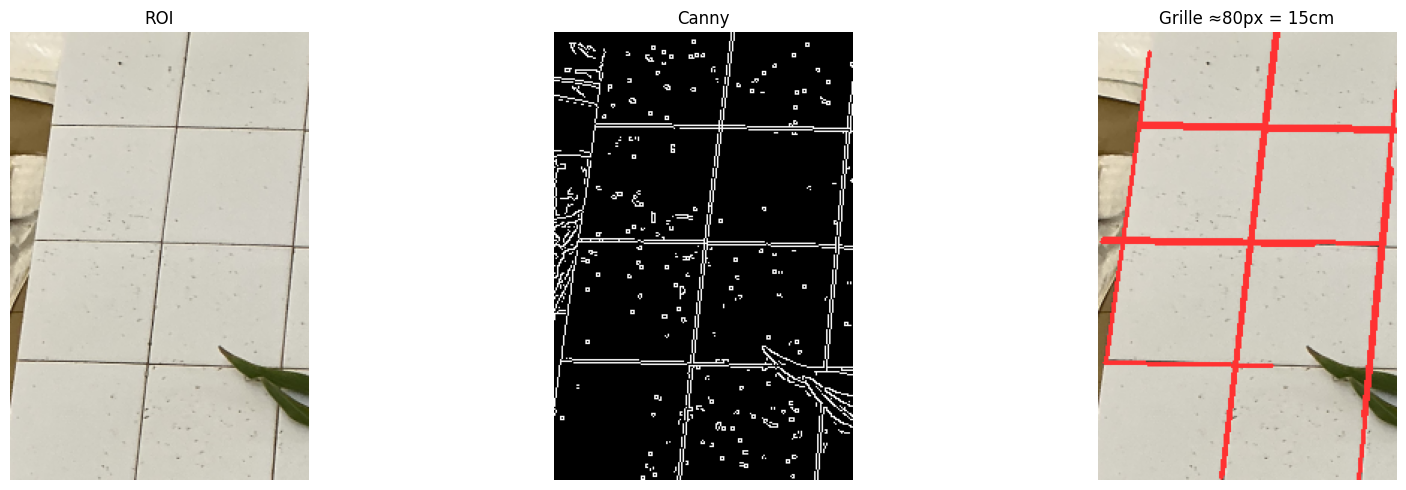


✅ 1px = 0.18750cm — sauvegardé


In [109]:
INDEX_CALIB = 0
ROI_CALIB   = (0, 0, 200, 300)  # ← zone propre sans plante

def calibrer_grille(image_rgb, roi=None, taille_cm=9.5, afficher=True):
    img = image_rgb[roi[1]:roi[3],roi[0]:roi[2]] if roi else image_rgb
    gris  = cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gris,30,80,apertureSize=3)
    lignes = cv2.HoughLinesP(edges,1,np.pi/180,threshold=100,
                              minLineLength=60,maxLineGap=20)
    if lignes is None:
        print('⚠️  Aucune ligne détectée → utilise Cellule A bis')
        return None
    ph,pv=[],[]
    for l in lignes:
        x1,y1,x2,y2=l[0]; ang=abs(np.degrees(np.arctan2(y2-y1,x2-x1)))
        if ang<15: ph.append((y1+y2)/2)
        elif ang>75: pv.append((x1+x2)/2)
    def esp(pos):
        ps=sorted(set([round(p/10)*10 for p in pos]))
        return [ps[i+1]-ps[i] for i in range(len(ps)-1) if 30<ps[i+1]-ps[i]<350]
    eh,ev=esp(ph),esp(pv)
    if not eh or not ev:
        print('⚠️  Espacements non calculables → utilise Cellule A bis')
        return None
    taille_px=(np.median(eh)+np.median(ev))/2
    print(f'📏 H:{np.median(eh):.1f}px  V:{np.median(ev):.1f}px  Moy:{taille_px:.1f}px = {taille_cm}cm')
    if afficher:
        fig,ax=plt.subplots(1,3,figsize=(18,5))
        ax[0].imshow(img); ax[0].set_title('ROI'); ax[0].axis('off')
        ax[1].imshow(edges,cmap='gray'); ax[1].set_title('Canny'); ax[1].axis('off')
        img2=img.copy()
        for l in lignes:
            x1,y1,x2,y2=l[0]; cv2.line(img2,(x1,y1),(x2,y2),(255,50,50),2)
        ax[2].imshow(img2)
        ax[2].set_title(f'Grille ≈{taille_px:.0f}px = {taille_cm}cm')
        ax[2].axis('off'); plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR,'A_calibration.png'),
                    dpi=120,bbox_inches='tight')
        plt.show()
    return taille_px

img_calib,_ = charger_image(images_originales[INDEX_CALIB],max_dim=MAX_DIM)
taille_px   = calibrer_grille(img_calib,roi=ROI_CALIB,taille_cm=TAILLE_CARREAU_CM)

if taille_px:
    FACTEUR_PX_CM = taille_px / TAILLE_CARREAU_CM
    FACTEUR_CM_PX = TAILLE_CARREAU_CM / taille_px
    with open(os.path.join(OUTPUT_DIR,'facteur_calibration.json'),'w') as f:
        json.dump({'FACTEUR_CM_PX':FACTEUR_CM_PX,'FACTEUR_PX_CM':FACTEUR_PX_CM,
                   'taille_px':taille_px,'taille_cm':TAILLE_CARREAU_CM},f,indent=2)
    print(f'\n✅ 1px = {FACTEUR_CM_PX:.5f}cm — sauvegardé')
else:
    print('\n❌ Lance Cellule A bis')

### Cellule A bis — Calibration manuelle

In [96]:
# Uniquement si Cellule A échoue
TAILLE_CARREAU_PX_MANUELLE =  15  # ← MODIFIER
FACTEUR_PX_CM = TAILLE_CARREAU_PX_MANUELLE / TAILLE_CARREAU_CM
FACTEUR_CM_PX = TAILLE_CARREAU_CM / TAILLE_CARREAU_PX_MANUELLE
print(f'✅ Manuel : 1px = {FACTEUR_CM_PX:.5f}cm')

✅ Manuel : 1px = 1.00000cm


---
## 🎛️ Cellule NEW-1 — Calibration interactive des seuils HSV
> Equivalent des trackbars OpenCV, adapté pour Colab.  
> **Une seule fois** sur une image représentative — même éclairage pour tout le lot.  
> Déplace les curseurs jusqu'à ce que le masque blanc couvre parfaitement la plante.
>
> **Rappel plages OpenCV HSV :** H=0-179, S=0-255, V=0-255

In [110]:
# ---------------------------------------------------------------
# CELLULE NEW-1 — Trackbars HSV interactifs
# ---------------------------------------------------------------

INDEX_CALIB_HSV = 0 # ← image pour calibrer les seuils

img_bgr_hsv = cv2.imread(images_originales[INDEX_CALIB_HSV])
img_rgb_hsv = cv2.cvtColor(img_bgr_hsv, cv2.COLOR_BGR2RGB)
hsv_calib   = cv2.cvtColor(img_bgr_hsv, cv2.COLOR_BGR2HSV)


# Ajouter juste après avoir chargé l'image de calibration
img_bgr_hsv = normaliser_exposition(img_bgr_hsv, clipLimit=2.0)
img_rgb_hsv = cv2.cvtColor(img_bgr_hsv, cv2.COLOR_BGR2RGB)
hsv_calib   = cv2.cvtColor(img_bgr_hsv, cv2.COLOR_BGR2HSV)



print(f'📷 {os.path.basename(images_originales[INDEX_CALIB_HSV])}')
print('🎛️  Déplace les curseurs — le masque blanc doit couvrir toute la plante')
print('   (H=teinte, S=saturation, V=luminosité)\n')

out_hsv = widgets.Output()

def preview_hsv(low_h, low_s, low_v, high_h, high_s, high_v):
    resultat, masque = appliquer_masque_hsv(
        img_bgr_hsv,
        [low_h, low_s, low_v],
        [high_h, high_s, high_v]
    )
    with out_hsv:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(18, 7))

        axes[0].imshow(img_rgb_hsv)
        axes[0].set_title('Originale', fontsize=12)
        axes[0].axis('off')

        axes[1].imshow(masque, cmap='gray')
        axes[1].set_title(
            f'Masque HSV\n'
            f'H:[{low_h}-{high_h}]  S:[{low_s}-{high_s}]  V:[{low_v}-{high_v}]',
            fontsize=11)
        axes[1].axis('off')

        axes[2].imshow(resultat)
        axes[2].set_title('Résultat — fond noir', fontsize=12)
        axes[2].axis('off')

        plt.tight_layout()
        plt.show()

        print(f'📋 Valeurs à copier dans Cellule NEW-2 :')
        print(f'   HSV_LOW  = [{low_h}, {low_s}, {low_v}]')
        print(f'   HSV_HIGH = [{high_h}, {high_s}, {high_v}]')


style  = {'description_width': '70px'}
layout = widgets.Layout(width='500px')

sliders = widgets.interactive(
    preview_hsv,
    low_h  = IntSlider(min=0,   max=179, step=1, value=15,
                        description='Low  H', style=style, layout=layout,
                        continuous_update=False),
    low_s  = IntSlider(min=0,   max=255, step=1, value=30,
                        description='Low  S', style=style, layout=layout,
                        continuous_update=False),
    low_v  = IntSlider(min=0,   max=255, step=1, value=20,
                        description='Low  V', style=style, layout=layout,
                        continuous_update=False),
    high_h = IntSlider(min=0,   max=179, step=1, value=90,
                        description='High H', style=style, layout=layout,
                        continuous_update=False),
    high_s = IntSlider(min=0,   max=255, step=1, value=255,
                        description='High S', style=style, layout=layout,
                        continuous_update=False),
    high_v = IntSlider(min=0,   max=255, step=1, value=255,
                        description='High V', style=style, layout=layout,
                        continuous_update=False),
)
display(sliders, out_hsv)

📷 IMG_1088.jpeg
🎛️  Déplace les curseurs — le masque blanc doit couvrir toute la plante
   (H=teinte, S=saturation, V=luminosité)



interactive(children=(IntSlider(value=15, continuous_update=False, description='Low  H', layout=Layout(width='…

Output()

---
## 🪄 Cellule NEW-2 — Extraction plante sur tout le lot
> Colle ici les valeurs HSV trouvées en NEW-1.  
> Applique l'extraction sur toutes les images → sauvegarde dans `images_nobg/`.

✅ Seuils sauvegardés : LOW=[22, 32, 20]  HIGH=[90, 255, 255]



Extraction plante: 100%|██████████| 61/61 [00:00<00:00, 7158.12it/s]


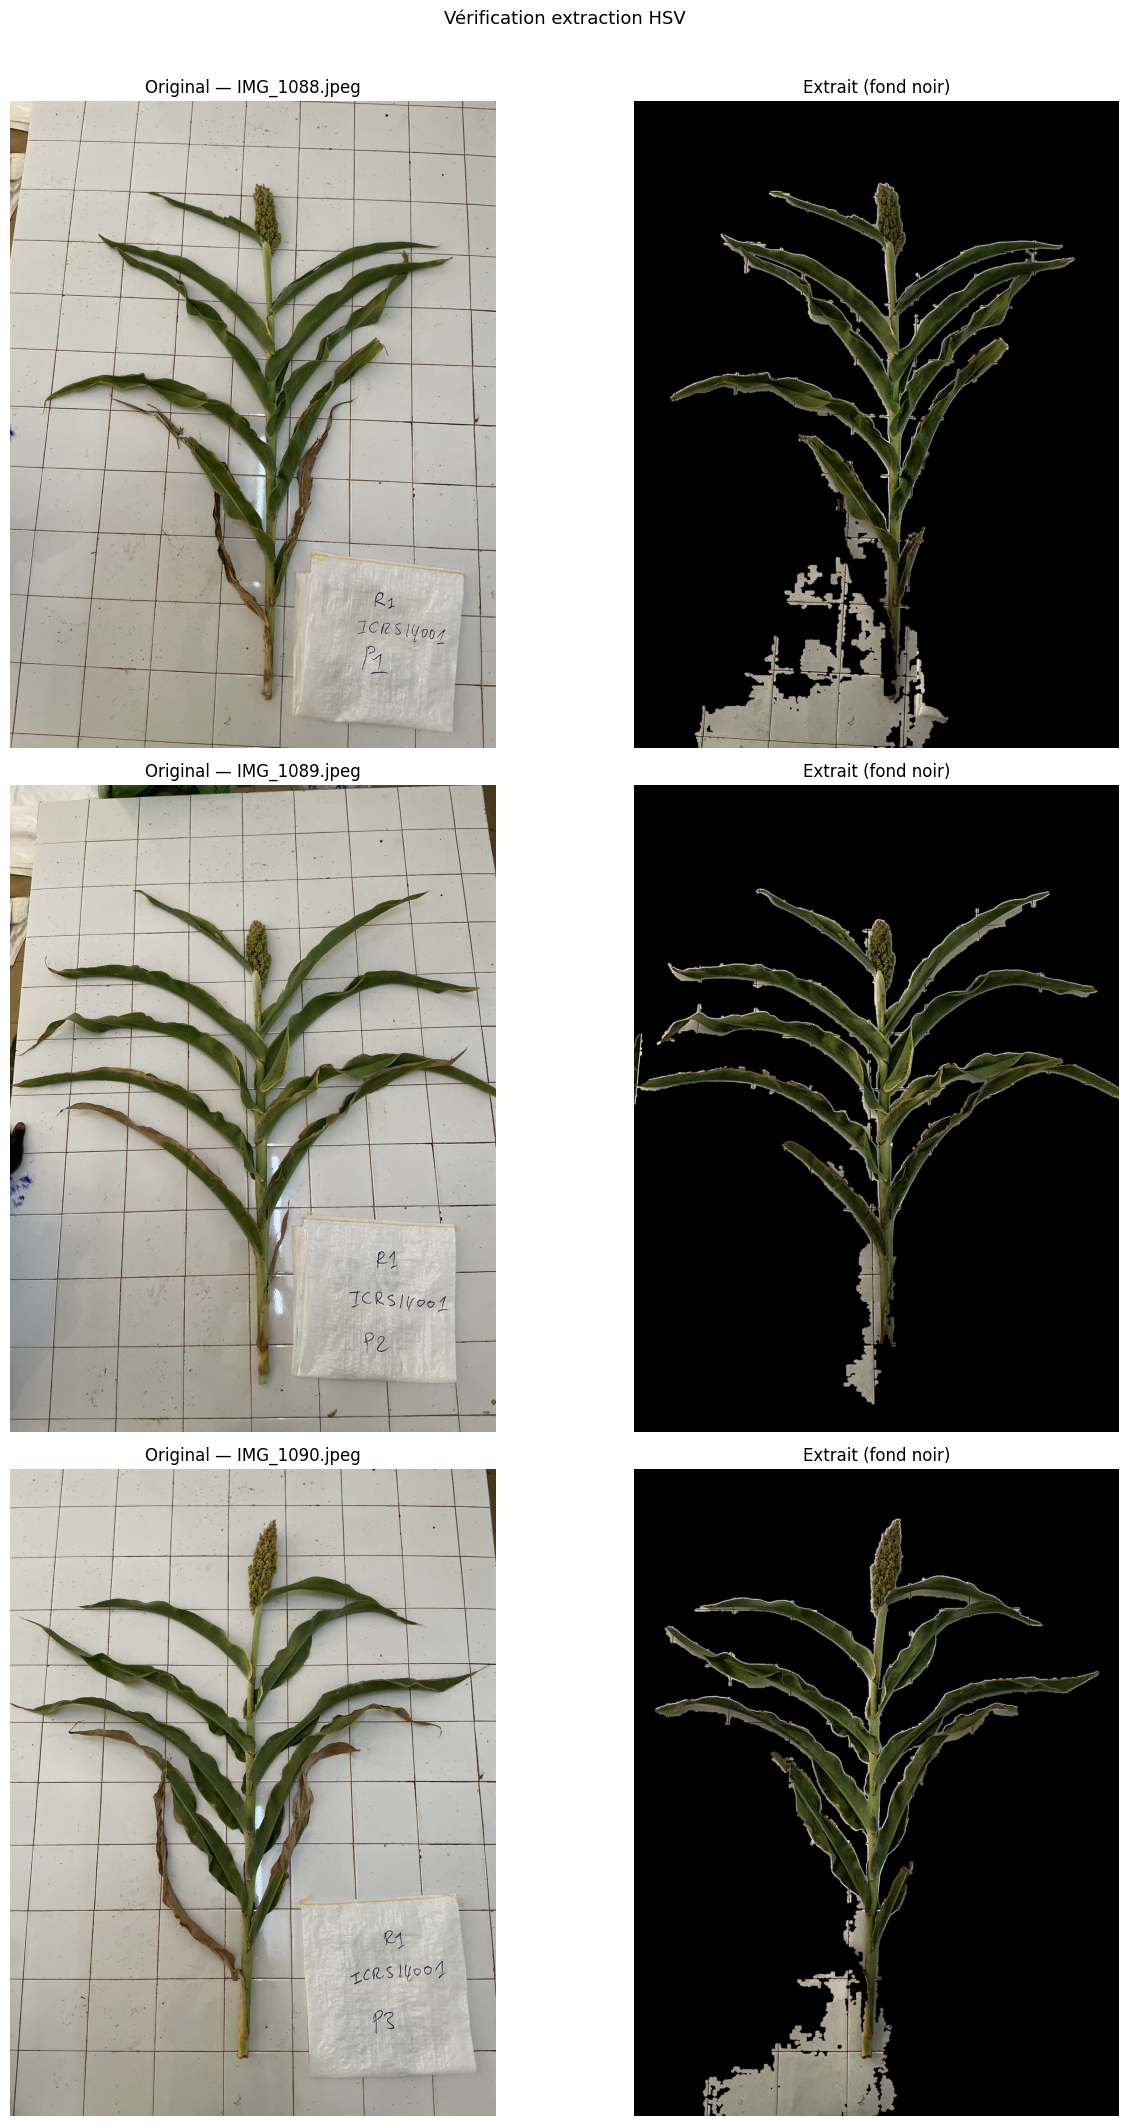

💡 Si le résultat n est pas satisfaisant, retourne en NEW-1 pour ajuster les seuils.


In [98]:
# ---------------------------------------------------------------
# CELLULE NEW-2 — Application sur tout le lot
# ---------------------------------------------------------------

# 🔧 COLLER ICI LES VALEURS DE NEW-1
HSV_LOW  = [22,  32,  20]   # ← MODIFIER
HSV_HIGH = [90, 255, 255]   # ← MODIFIER

# Sauvegarde des seuils sur Drive
with open(HSV_JSON,'w') as f:
    json.dump({'HSV_LOW':HSV_LOW,'HSV_HIGH':HSV_HIGH},f,indent=2)
print(f'✅ Seuils sauvegardés : LOW={HSV_LOW}  HIGH={HSV_HIGH}\n')

images_nobg = []

for chemin in tqdm(images_originales, desc='Extraction plante'):
    nom    = os.path.splitext(os.path.basename(chemin))[0]
    sortie = os.path.join(IMAGES_NOBG_DIR, f'{nom}_nobg.png')

    if not os.path.exists(sortie):
        bgr = cv2.imread(chemin)

        # ← ÉTAPE 1 : normalisation exposition
        bgr_norm = normaliser_exposition(bgr, clipLimit=2.0)

        # ← ÉTAPE 2 : extraction HSV (sur image normalisée)
        resultat, _ = appliquer_masque_hsv(bgr_norm, HSV_LOW, HSV_HIGH)

        cv2.imwrite(sortie, cv2.cvtColor(resultat, cv2.COLOR_RGB2BGR))

    images_nobg.append(sortie)

# ── Vérification visuelle côte à côte (original vs extrait) ──
NB_VERIF = min(3, len(images_nobg))   # afficher les 3 premières
fig, axes = plt.subplots(NB_VERIF, 2, figsize=(14, 7*NB_VERIF))
if NB_VERIF == 1: axes = [axes]

for i in range(NB_VERIF):
    orig = cv2.cvtColor(cv2.imread(images_originales[i]), cv2.COLOR_BGR2RGB)
    nobg = cv2.cvtColor(cv2.imread(images_nobg[i]),       cv2.COLOR_BGR2RGB)
    nom  = os.path.basename(images_originales[i])
    axes[i][0].imshow(orig); axes[i][0].set_title(f'Original — {nom}');  axes[i][0].axis('off')
    axes[i][1].imshow(nobg); axes[i][1].set_title('Extrait (fond noir)'); axes[i][1].axis('off')

plt.suptitle('Vérification extraction HSV', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'NEW2_verification.png'),
            dpi=120, bbox_inches='tight')
plt.show()
print('💡 Si le résultat n est pas satisfaisant, retourne en NEW-1 pour ajuster les seuils.')

---
## 🖱️ Cellule B — Définition des points de référence
> À faire **une seule fois** sur une image sans fond.  
> Ordre : 1 panicule → 8 feuilles (pointes) → 1 tige

📷 IMG_1089_nobg.png
   🔄 3024×4032 → 768×1024 px



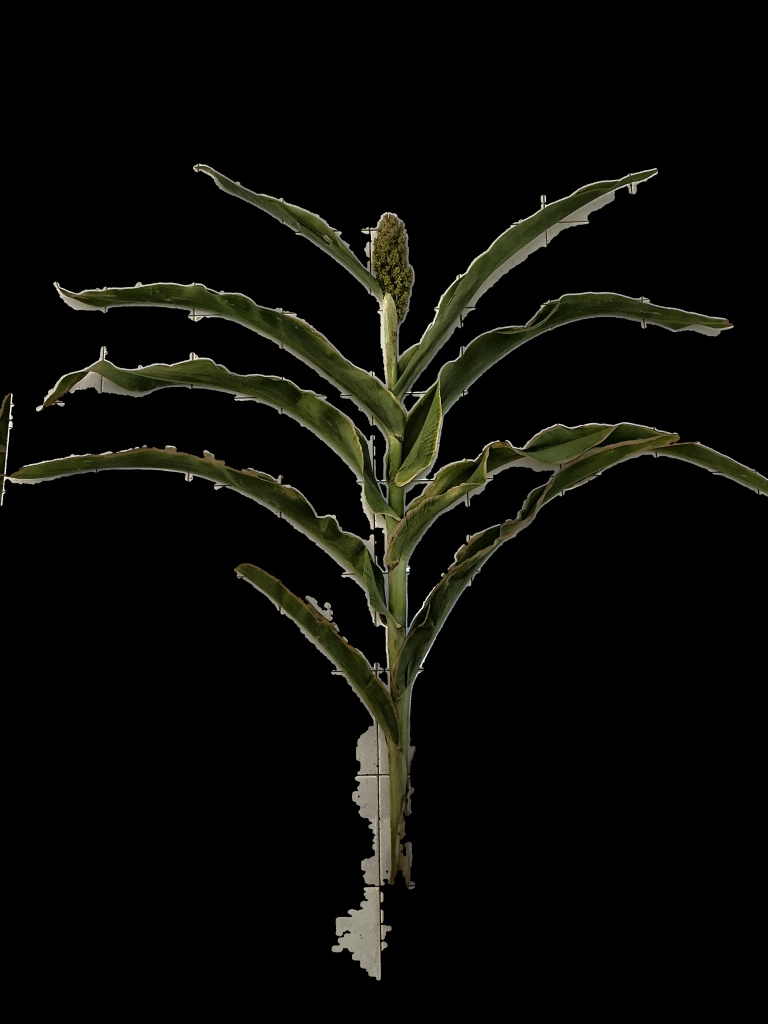

In [102]:
my_index=1

INDEX_REF = my_index
img_ref_path = images_nobg[INDEX_REF]
print(f'📷 {os.path.basename(img_ref_path)}')
img_ref, scale_ref = charger_image(img_ref_path, max_dim=MAX_DIM)
h_ref, w_ref = img_ref.shape[:2]

_, buf = cv2.imencode('.jpg', cv2.cvtColor(img_ref, cv2.COLOR_RGB2BGR))
img_b64 = base64.b64encode(buf).decode('utf-8')

NOMS = ['panicule']+[f'feuille_{i}' for i in range(1,NB_FEUILLES+1)]+['tige']
CLRS = ['#e74c3c']+['#27ae60']*NB_FEUILLES+['#8e44ad']
noms_js=json.dumps(NOMS); clrs_js=json.dumps(CLRS)

html = f"""
<div style="font-family:monospace;font-size:13px;">
<p style="color:#c0392b;font-weight:bold;line-height:1.8">
  Clique dans l'ordre :<br>
  🔴 1. Panicule — centre de l'épi<br>
  🟢 2→{NB_FEUILLES+1}. Feuilles 1→{NB_FEUILLES} — <b>pointe</b> de chaque feuille (haut → bas)<br>
  🟣 {NB_FEUILLES+2}. Tige — tige nue partie basse
</p>
<div style="position:relative;display:inline-block;">
  <img id="imgB" src="data:image/jpeg;base64,{img_b64}"
       width="{w_ref}" height="{h_ref}"
       style="display:block;cursor:crosshair;border:2px solid #ccc;"/>
  <canvas id="cvB" width="{w_ref}" height="{h_ref}"
          style="position:absolute;top:0;left:0;pointer-events:none;"></canvas>
</div>
<p id="prchB" style="color:#27ae60;font-weight:bold;margin:8px 0">
  Prochain : panicule (1/{len(NOMS)})
</p>
<pre id="outB" style="background:#f5f5f5;padding:10px;border-radius:6px;
     min-height:40px;color:#2c3e50;">En attente...</pre>
<div style="display:flex;gap:8px;margin-top:8px;">
  <button onclick="eff()" style="padding:6px 16px;cursor:pointer;
    background:#e74c3c;color:white;border:none;border-radius:4px;">Effacer tout</button>
  <button onclick="ann()" style="padding:6px 16px;cursor:pointer;
    background:#e67e22;color:white;border:none;border-radius:4px;">Annuler dernier</button>
  <button onclick="cop()" style="padding:6px 16px;cursor:pointer;
    background:#27ae60;color:white;border:none;border-radius:4px;">Copier JSON</button>
</div></div>
<script>
const noms={noms_js},clrs={clrs_js},total=noms.length;
let pts=[];
const img=document.getElementById('imgB'),cv=document.getElementById('cvB'),
      ctx=cv.getContext('2d'),out=document.getElementById('outB'),
      prch=document.getElementById('prchB');
function draw(p,i){{
  ctx.beginPath();ctx.arc(p.x,p.y,9,0,2*Math.PI);
  ctx.fillStyle=clrs[i];ctx.fill();
  ctx.strokeStyle='white';ctx.lineWidth=2;ctx.stroke();
  ctx.fillStyle='white';ctx.font='bold 10px monospace';
  ctx.textAlign='center';ctx.textBaseline='middle';
  ctx.fillText(i+1,p.x,p.y);
  ctx.fillStyle=clrs[i];ctx.font='bold 11px monospace';
  ctx.textAlign='left';
  ctx.fillText(noms[i]+'('+p.x+','+p.y+')',p.x+13,p.y);
}}
img.addEventListener('click',e=>{{
  if(pts.length>=total)return;
  const r=img.getBoundingClientRect();
  const x=Math.round(e.clientX-r.left),y=Math.round(e.clientY-r.top);
  const i=pts.length;pts.push({{nom:noms[i],x,y}});draw(pts[i],i);
  if(pts.length<total){{
    const s=noms[pts.length];
    const lb=s==='tige'?'(tige nue partie basse)':
             s.includes('feuille')?'(pointe de la feuille)':'(centre de l épi)';
    prch.textContent='Prochain : '+s+' '+lb+' ('+(pts.length+1)+'/'+total+')';
  }}else prch.textContent='✅ Tous les points collectés !';
  show();
}});
function show(){{
  if(!pts.length){{out.textContent='En attente...';return;}}
  let o={{}};
  pts.forEach(p=>{{o[p.nom]={{coords:[[p.x,p.y]],labels:[1]}};}});
  out.textContent=JSON.stringify(o,null,2);
}}
function eff(){{
  pts=[];ctx.clearRect(0,0,cv.width,cv.height);
  out.textContent='En attente...';
  prch.textContent='Prochain : panicule (1/'+total+')';
}}
function ann(){{
  if(!pts.length)return;pts.pop();
  ctx.clearRect(0,0,cv.width,cv.height);
  pts.forEach((p,i)=>draw(p,i));
  if(pts.length<total)
    prch.textContent='Prochain : '+noms[pts.length]+' ('+(pts.length+1)+'/'+total+')';
  show();
}}
function cop(){{
  navigator.clipboard.writeText(out.textContent).then(()=>alert('JSON copié !'));
}}
</script>"""
display(HTML(html))

In [103]:
# CELLULE B (suite) — Coller le JSON et sauvegarder
JSON_POINTS = """
{
  "panicule": {
    "coords": [
      [
        395,
        254
      ]
    ],
    "labels": [
      1
    ]
  },
  "feuille_1": {
    "coords": [
      [
        476,
        277
      ]
    ],
    "labels": [
      1
    ]
  },
  "feuille_2": {
    "coords": [
      [
        323,
        353
      ]
    ],
    "labels": [
      1
    ]
  },
  "feuille_3": {
    "coords": [
      [
        487,
        362
      ]
    ],
    "labels": [
      1
    ]
  },
  "feuille_4": {
    "coords": [
      [
        322,
        418
      ]
    ],
    "labels": [
      1
    ]
  },
  "feuille_5": {
    "coords": [
      [
        460,
        494
      ]
    ],
    "labels": [
      1
    ]
  },
  "feuille_6": {
    "coords": [
      [
        328,
        540
      ]
    ],
    "labels": [
      1
    ]
  },
  "feuille_7": {
    "coords": [
      [
        430,
        627
      ]
    ],
    "labels": [
      1
    ]
  },
  "feuille_8": {
    "coords": [
      [
        345,
        652
      ]
    ],
    "labels": [
      1
    ]
  }
}

"""   # ← REMPLACER PAR TON JSON

POINTS_REFERENCE = json.loads(JSON_POINTS)
with open(POINTS_JSON,'w') as f:
    json.dump(POINTS_REFERENCE,f,indent=2)
print(f'✅ Points sauvegardés : {list(POINTS_REFERENCE.keys())}')

✅ Points sauvegardés : ['panicule', 'feuille_1', 'feuille_2', 'feuille_3', 'feuille_4', 'feuille_5', 'feuille_6', 'feuille_7', 'feuille_8']


---
## ✅ Cellule C — Validation sur image de référence

📷 IMG_1089_nobg.png
Facteur : 0.25397 cm/px

   ✅ panicule     L=26.2cm l=9.6cm A=187.4cm² ∠=82.0°
   ✅ feuille_1    L=73.5cm l=19.2cm A=540.3cm² ∠=41.6°
   ✅ feuille_2    L=83.0cm l=32.5cm A=619.9cm² ∠=19.7°
   ✅ feuille_3    L=44.2cm l=10.1cm A=214.8cm² ∠=35.6°
   ✅ feuille_4    L=89.8cm l=51.3cm A=559.3cm² ∠=11.2°
   ✅ feuille_5    L=32.5cm l=9.7cm A=162.5cm² ∠=40.1°
   ✅ feuille_6    L=124.7cm l=81.6cm A=551.1cm² ∠=4.4°
   ✅ feuille_7    L=54.1cm l=9.3cm A=282.3cm² ∠=55.1°
   ✅ feuille_8    L=62.5cm l=9.4cm A=333.6cm² ∠=46.7°

🌿 9/9 organe(s)
✅ Tous détectés — prêt pour Cellule D


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/SAM_SORGHUM/folder2025/outputs/visualisations/IMG_1089_traits.png'

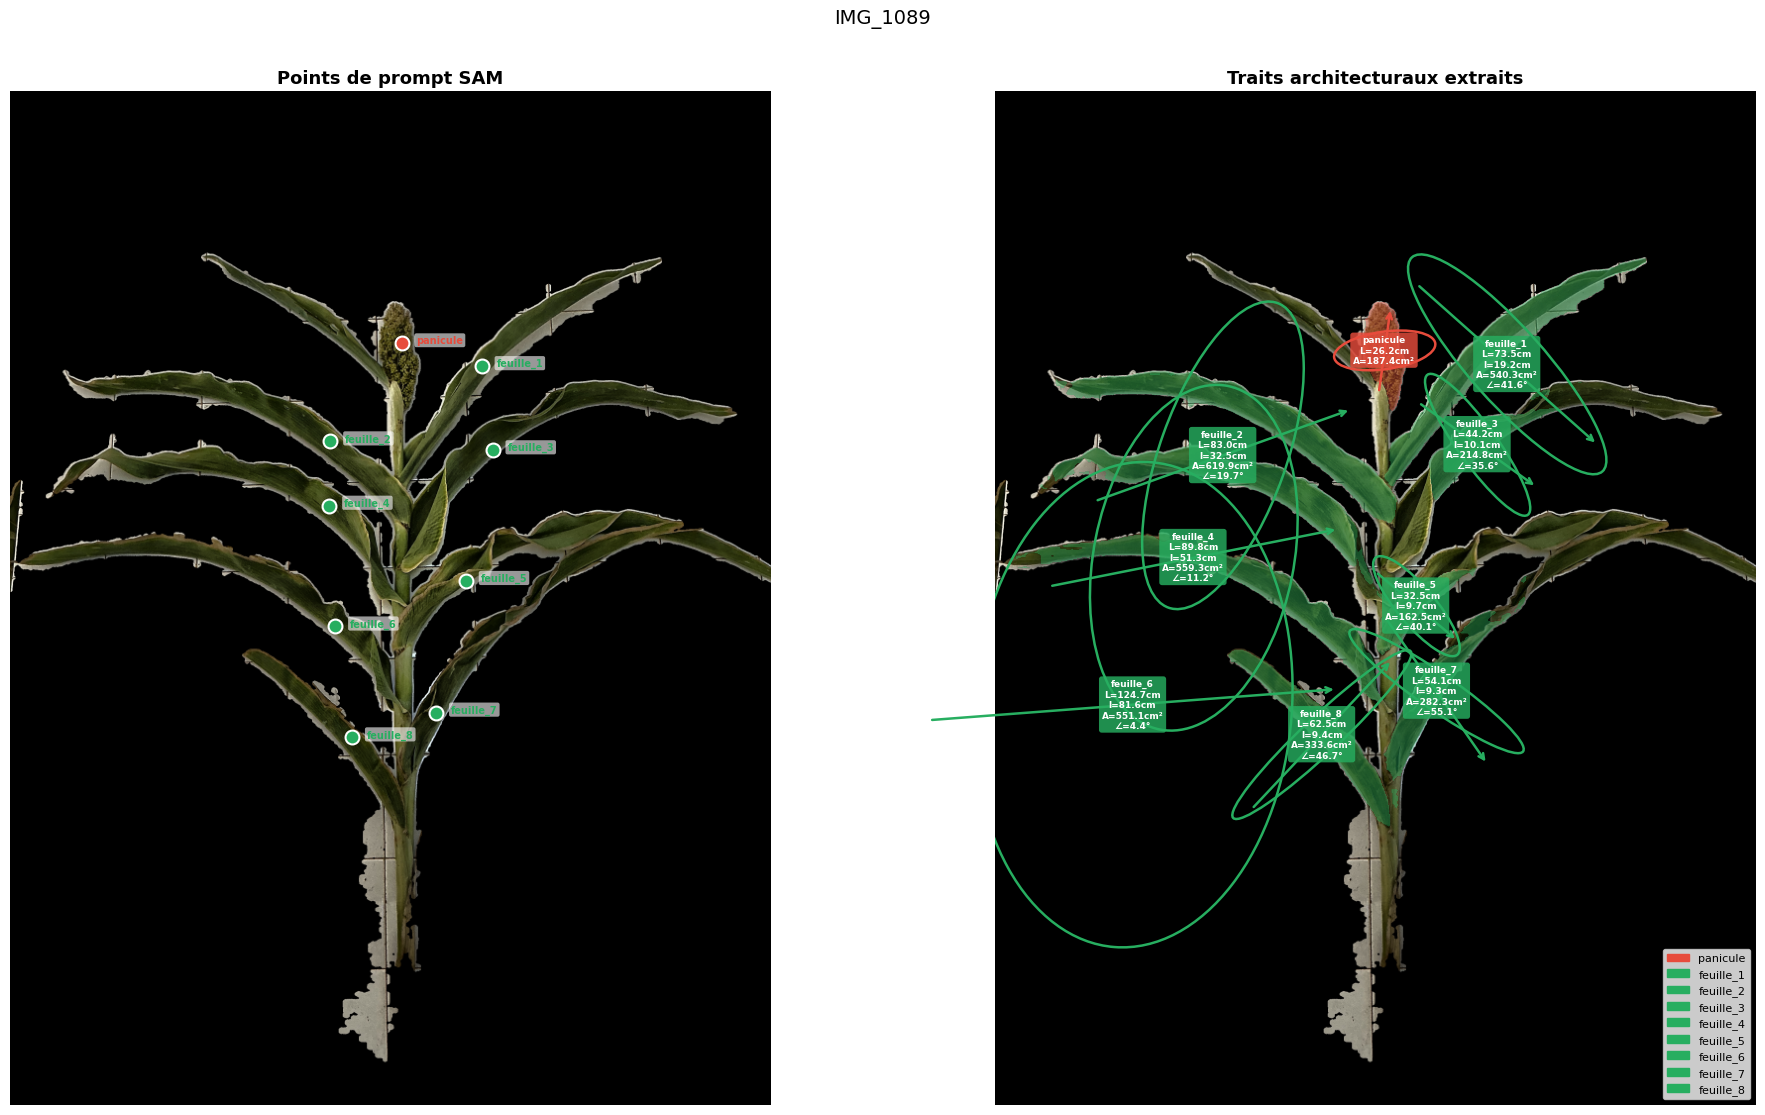

In [104]:
with open(POINTS_JSON) as f: POINTS_REFERENCE=json.load(f)

print(f'📷 {os.path.basename(img_ref_path)}')
facteur_ref = FACTEUR_CM_PX * scale_ref
print(f'Facteur : {facteur_ref:.5f} cm/px\n')

predictor   = SamPredictor(sam)
organes_ref = segmenter_image(img_ref,POINTS_REFERENCE,predictor,facteur_ref)

print(f'\n🌿 {len(organes_ref)}/{len(POINTS_REFERENCE)} organe(s)')
manquants=[k for k in POINTS_REFERENCE if k not in organes_ref]
if manquants: print(f'⚠️  Manquants : {manquants} → ajuster Cellule B')
else: print('✅ Tous détectés — prêt pour Cellule D')

nom_ref    = os.path.splitext(os.path.basename(img_ref_path))[0].replace('_nobg','')
chemin_fig = visualiser(img_ref,organes_ref,POINTS_REFERENCE,
                        nom_ref,OUTPUT_DIR,sauvegarder=True)
IPImage(chemin_fig)

---
## 🔬 Cellule D — Traitement image par image
> Changer `INDEX_IMAGE` → lancer → valider → lancer Cellule E

📷 [15/694] IMG_20251125_104929_441
──────────────────────────────────────────────────
   🔄 3120×4160 → 768×1024 px

   ✅ panicule     L=15.6cm l=7.4cm A=87.3cm² ∠=84.7°
   ✅ feuille_1    L=41.8cm l=3.1cm A=73.3cm² ∠=19.9°
   ✅ feuille_2    L=56.1cm l=5.8cm A=184.3cm² ∠=24.3°
   ✅ feuille_3    L=63.2cm l=7.4cm A=329.1cm² ∠=54.1°
   ✅ feuille_4    L=58.4cm l=7.7cm A=235.4cm² ∠=57.0°
   ✅ feuille_5    L=77.2cm l=5.3cm A=267.5cm² ∠=69.6°
   ✅ feuille_6    L=41.9cm l=5.4cm A=174.1cm² ∠=72.1°

🌿 7/7 organe(s)


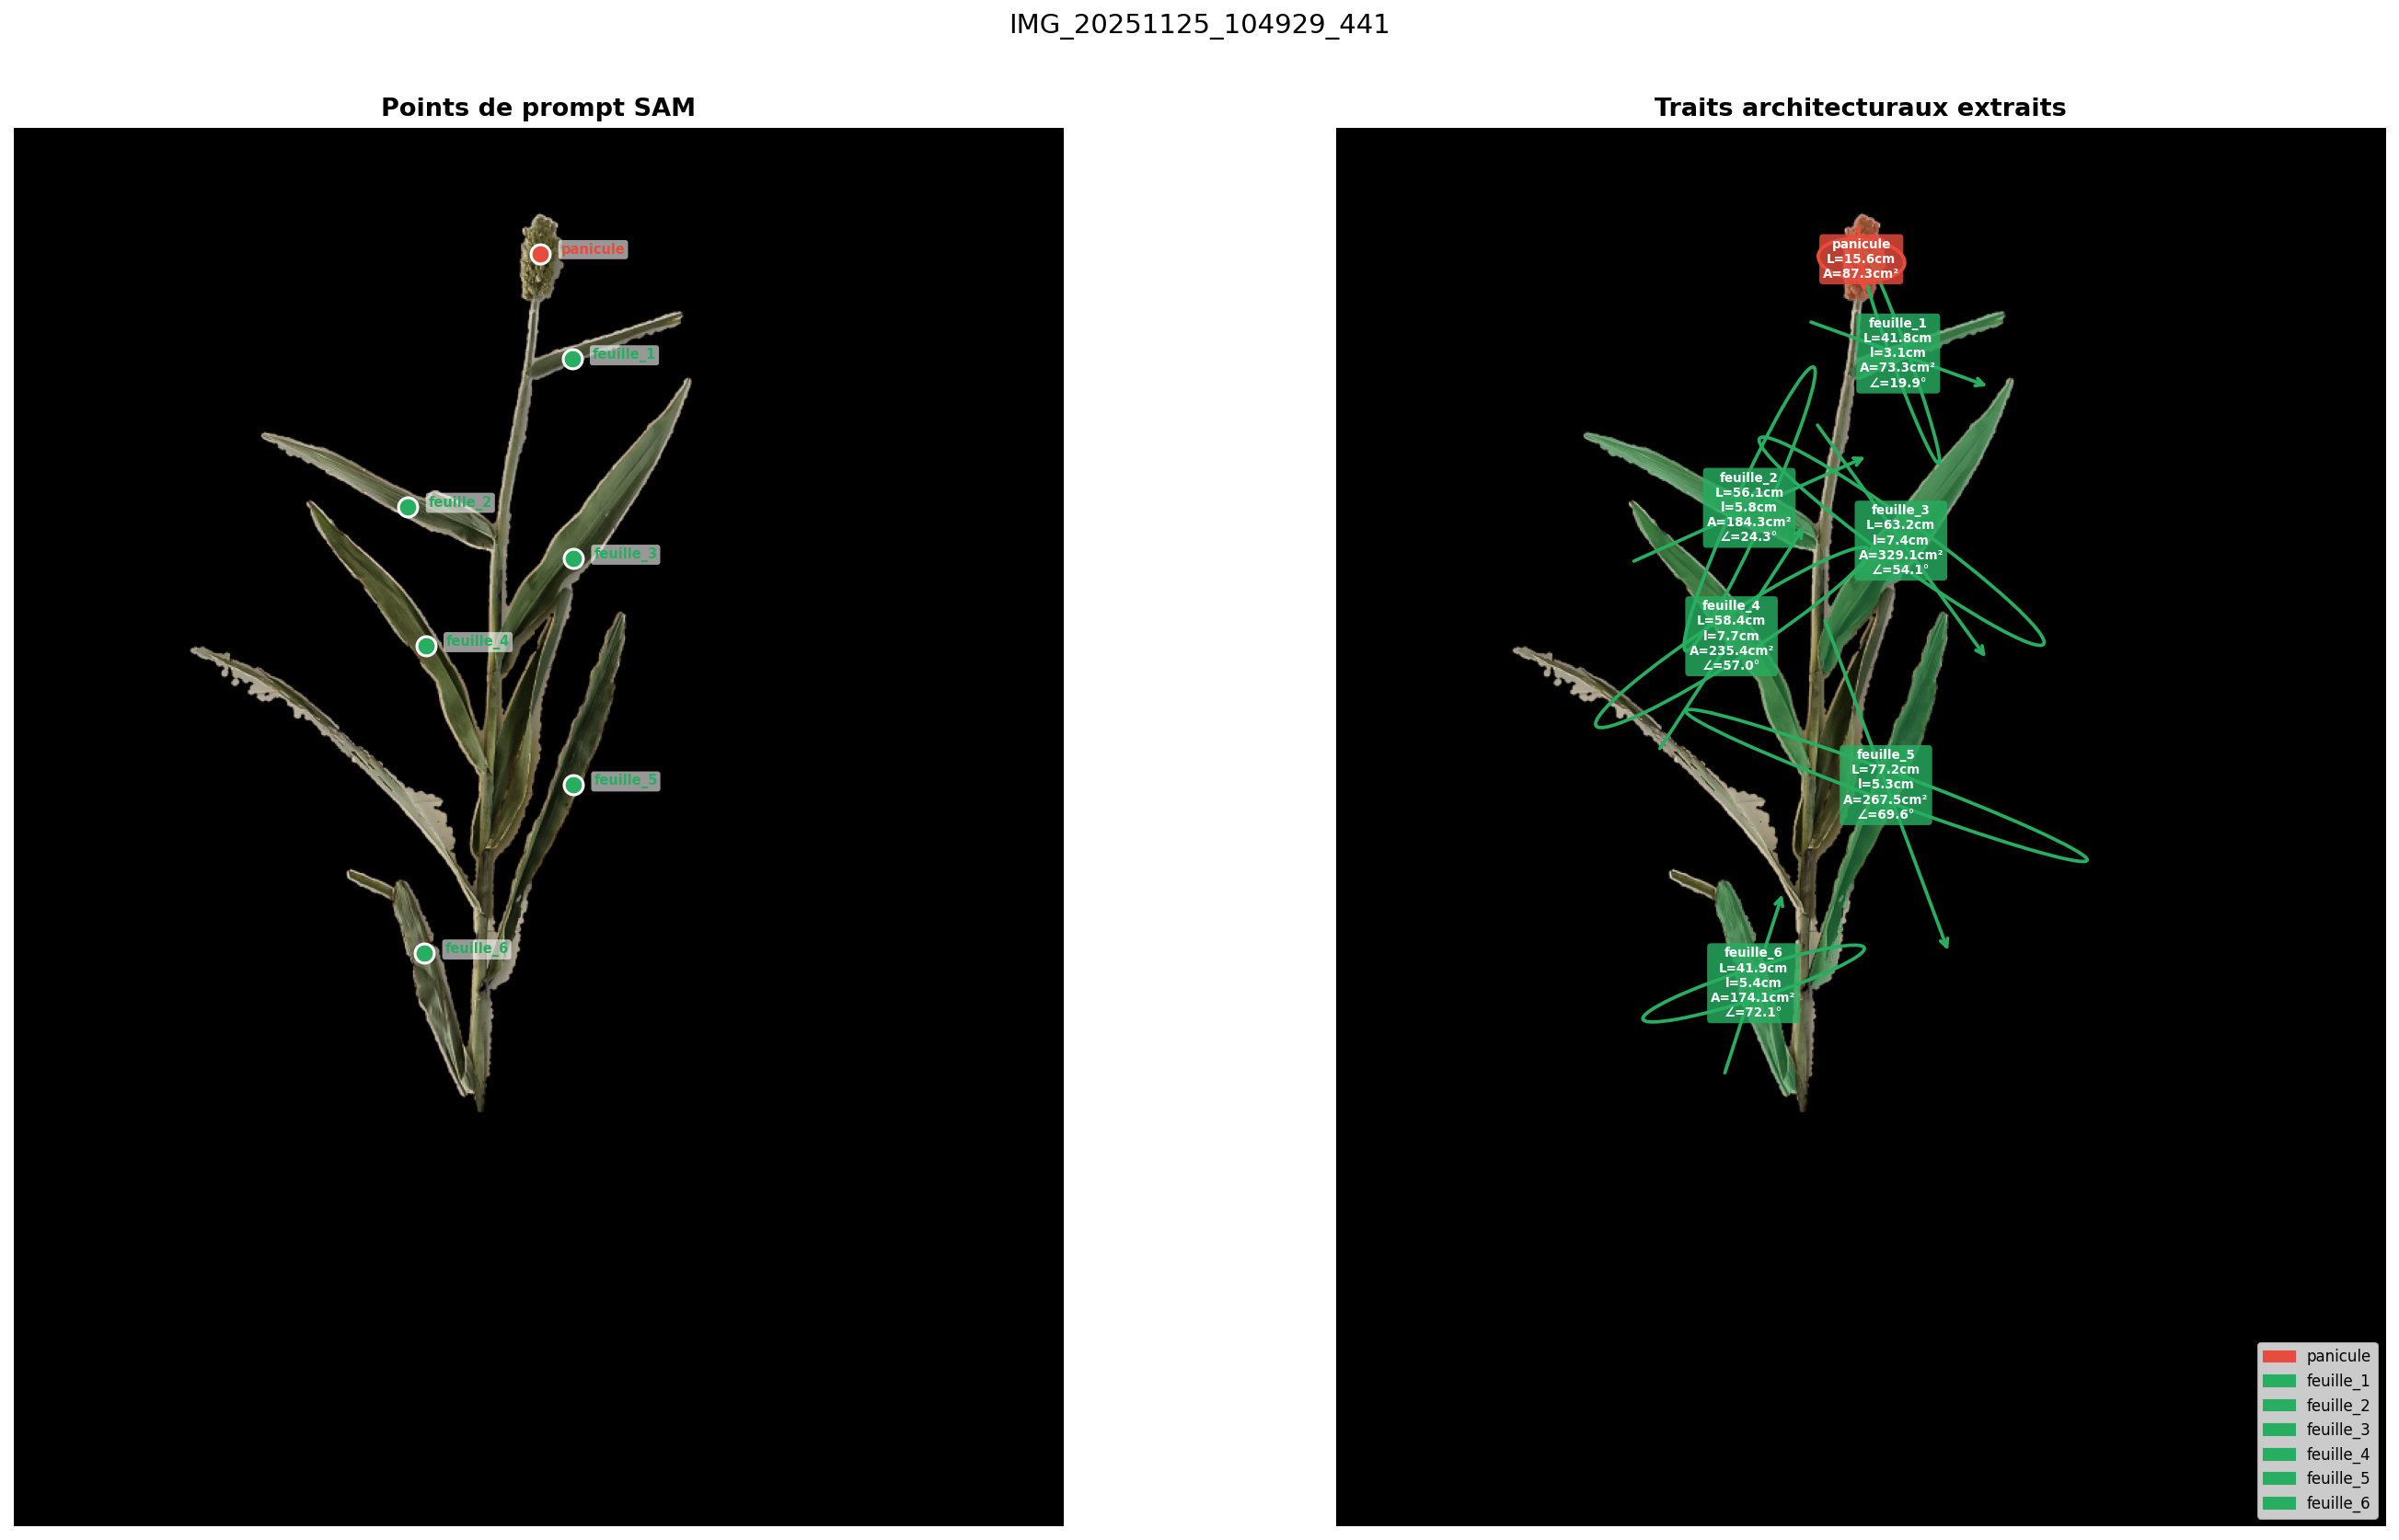

In [80]:
INDEX_IMAGE = my_index   # ← CHANGER POUR CHAQUE IMAGE

chemin_img   = images_nobg[INDEX_IMAGE]
nom_img      = os.path.splitext(os.path.basename(chemin_img))[0]
nom_original = nom_img.replace('_nobg','')

print(f'📷 [{INDEX_IMAGE+1}/{len(images_nobg)}] {nom_original}')
print('─'*50)

image_rgb,scale = charger_image(chemin_img,max_dim=MAX_DIM)
facteur         = FACTEUR_CM_PX * scale

with open(POINTS_JSON) as f: POINTS_REFERENCE=json.load(f)

torch.cuda.empty_cache()
predictor = SamPredictor(sam)
print()
organes_courants = segmenter_image(image_rgb,POINTS_REFERENCE,predictor,facteur)

print(f'\n🌿 {len(organes_courants)}/{len(POINTS_REFERENCE)} organe(s)')
manquants=[k for k in POINTS_REFERENCE if k not in organes_courants]
if manquants: print(f'⚠️  Manquants : {manquants}')

chemin_fig=visualiser(image_rgb,organes_courants,POINTS_REFERENCE,
                      nom_original,OUTPUT_DIR,sauvegarder=True)
IPImage(chemin_fig)

---
## 💾 Cellule E — Sauvegarde CSV individuel + fusion finale

In [33]:
# CSV individuel nommé comme l'image originale
ligne = resultats_vers_csv(nom_original,organes_courants,NB_FEUILLES)
ligne['nb_organes_detectes'] = len(organes_courants)
ligne['organes_manquants']   = ','.join(manquants) if manquants else ''

chemin_csv = os.path.join(OUTPUT_DIR,'csv',f'{nom_original}.csv')
pd.DataFrame([ligne]).to_csv(chemin_csv,index=False,encoding='utf-8-sig')

print(f'✅ {nom_original}.csv sauvegardé')
display(pd.DataFrame([ligne]).T.rename(columns={0:'valeur'}))

✅ IMG_20251125_091336_365.csv sauvegardé


,valeur
image,IMG_20251125_091336_365
panicule_L_cm,23.808
panicule_A_cm2,98.4009
f1_L_cm,37.766
f1_l_cm,10.641
f1_A_cm2,308.1392
f1_angle_deg,47.1
f2_L_cm,31.332
f2_l_cm,6.546
f2_A_cm2,106.0658


In [ ]:
# ── FUSION FINALE ── À lancer quand toutes les images sont traitées
tous_csv = sorted(glob.glob(os.path.join(OUTPUT_DIR,'csv','*.csv')))

if not tous_csv:
    print('⚠️  Aucun CSV — traite d abord les images avec Cellule D + E')
else:
    df_final = pd.concat([pd.read_csv(f) for f in tous_csv],ignore_index=True)
    chemin_final = os.path.join(OUTPUT_DIR,'traits_architecturaux_FINAL.csv')
    df_final.to_csv(chemin_final,index=False,encoding='utf-8-sig')

    print(f'✅ {len(df_final)} image(s) → traits_architecturaux_FINAL.csv')
    print(f'   {len(df_final.columns)} colonnes')
    display(df_final.head())

    print('\n📊 Statistiques descriptives :')
    cols=[c for c in df_final.select_dtypes(include='number').columns
          if 'px' not in c and 'detectes' not in c]
    display(df_final[cols].describe().round(3))

    print('\n📥 Import dans R :')
    print('   df <- read.csv("traits_architecturaux_FINAL.csv", header=TRUE)')

✅ 50 image(s) → traits_architecturaux_FINAL.csv
   39 colonnes


,image,panicule_L_cm,panicule_A_cm2,f1_L_cm,f1_l_cm,f1_A_cm2,f1_angle_deg,f2_L_cm,f2_l_cm,f2_A_cm2,...,f7_A_cm2,f7_angle_deg,f8_L_cm,f8_l_cm,f8_A_cm2,f8_angle_deg,tige_L_cm,tige_diametre_cm,nb_organes_detectes,organes_manquants
0,IMG_1088,5.509,7.6718,10.651,0.949,5.6064,22.3,12.681,4.493,11.7867,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,NaN
1,IMG_1089,4.936,6.9345,10.788,1.567,7.8062,35.2,19.969,11.432,15.9198,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,NaN
2,IMG_1090,7.087,10.5507,14.537,7.017,15.1898,15.3,12.425,1.583,11.8497,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN
3,IMG_1091,7.483,11.6765,81.834,34.242,5.9769,42.4,14.844,1.592,13.1705,...,10.3473,60.5,14.506,1.894,12.7843,62.7,10.256,1.486,10,NaN
4,IMG_1092,6.447,8.5374,8.857,1.828,7.3074,57.5,6.291,1.539,5.0253,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,NaN



📊 Statistiques descriptives :


,panicule_L_cm,panicule_A_cm2,f1_L_cm,f1_l_cm,f1_A_cm2,f1_angle_deg,f2_L_cm,f2_l_cm,f2_A_cm2,f2_angle_deg,...,f7_L_cm,f7_l_cm,f7_A_cm2,f7_angle_deg,f8_L_cm,f8_l_cm,f8_A_cm2,f8_angle_deg,tige_L_cm,tige_diametre_cm
count,50.000,50.000,46.000,46.000,46.000,46.000,42.000,42.000,42.000,42.000,...,9.000,9.000,9.000,9.000,5.000,5.000,5.000,5.000,1.000,1.000
mean,6.246,8.841,16.094,4.746,12.845,50.874,13.608,3.423,15.869,53.343,...,12.051,1.264,8.959,71.156,17.042,3.948,36.543,70.660,10.256,1.486
std,0.756,1.268,18.203,8.335,20.371,21.029,6.371,3.512,24.849,14.194,...,2.831,0.209,1.778,7.581,12.363,5.547,61.936,7.195,NaN,NaN
min,4.238,5.937,4.986,0.854,3.330,8.400,4.615,0.874,2.012,19.600,...,6.008,0.924,6.599,60.500,5.857,1.241,6.452,62.700,10.256,1.486
25%,5.682,8.168,8.206,1.105,5.139,35.850,10.020,1.511,8.287,45.000,...,10.995,1.225,7.585,63.500,12.796,1.282,8.066,67.500,10.256,1.486
50%,6.417,8.807,10.030,1.889,6.841,49.100,12.868,2.157,10.251,50.500,...,12.275,1.251,9.918,73.500,13.768,1.463,8.158,67.600,10.256,1.486
75%,6.835,9.552,13.424,3.088,10.781,65.350,15.560,2.954,13.359,63.525,...,12.940,1.342,10.478,77.800,14.506,1.894,12.784,74.300,10.256,1.486
max,7.972,11.676,95.621,36.994,115.916,90.000,40.156,15.389,151.080,89.700,...,15.476,1.570,10.771,78.700,38.281,13.859,147.256,81.200,10.256,1.486



📥 Import dans R :
   df <- read.csv("traits_architecturaux_FINAL.csv", header=TRUE)
